<p align="center">
  <img src="https://capsule-render.vercel.app/api?type=waving&color=0:0f172a,50:1a56db,100:10b981&height=220&section=header&text=Visão+Computacional&fontSize=32&fontColor=ffffff&animation=fadeIn&fontAlignY=35&desc=Unidade%201%20%7C%20Cap%C3%ADtulo%201%20%7C%20Tarefa%202&descSize=20&descAlignY=55&descColor=94a3b8&pause=1500&duration=6000" width="100%" alt="Visão Computacional"/>
  <img src="https://readme-typing-svg.demolab.com/?lines=Fundamentos+de+Processamento+de+Imagens&pause=1500&duration=6000" />
</p>

**Prof.:** Alyson Bezerra

---

## Objetivo
Construir um mini dataset com **2 classes** e **10 imagens** no total, aplicando na prática os fundamentos discutidos em aula:

- Resolução e profundidade de cor
- Conversões de espaço de cor (RGB, HSV, escala de cinza)
- Aquisição (condições de captura)
- Armazenamento e formatos (RAW/JPEG/PNG)
- Análise de impacto visual e funcional das escolhas

Este notebook acompanha o relatório em markdown junto com os códigos.

## 1. Configuração do ambiente

Antes de executar este notebook, crie e ative o ambiente virtual e instale as dependências (uso o Jupiter localmente):

```bash
python3 -m venv venv
source venv/bin/activate          # Linux / macOS
# venv\Scripts\activate           # Windows
pip install --upgrade pip
pip install -r requirements.txt
python -m ipykernel install --user --name fpi-tarefa2 --display-name "Python (FPI Tarefa 2)"
```

Selecione o kernel **Python (FPI Tarefa 2)** no Jupyter.

## 2. Importação de pacotes

In [ ]:
!pip install -r ./requirements.txt

[2026-05-10 14:30:11] [2064050474.py:<module>:32] 🚀 Ambiente carregado - Python 3.12.3
[2026-05-10 14:30:11] [2064050474.py:<module>:33] ℹ️ NumPy 2.4.4 | OpenCV 4.13.0 | Pillow 12.2.0


In [ ]:
import os
import sys
import shutil
import logging
from pathlib import Path
from datetime import datetime

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# Configuração de logging estruturado
LOG_DIR = Path('logs')
LOG_DIR.mkdir(exist_ok=True)
log_file = LOG_DIR / f"notebook_{datetime.now().strftime('%Y%m%d')}.log"

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] [%(filename)s:%(funcName)s:%(lineno)d] %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
    handlers=[
        logging.FileHandler(log_file, encoding='utf-8'),
        logging.StreamHandler(sys.stdout),
    ],
)
log = logging.getLogger('fpi-tarefa2')

log.info('🚀 Ambiente carregado - Python %s', sys.version.split()[0])
log.info('ℹ️ NumPy %s | OpenCV %s | Pillow %s', np.__version__, cv2.__version__, Image.__version__)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

[2026-05-10 14:30:53] [3262878038.py:<module>:30] 🚀 Ambiente carregado - Python 3.12.3
[2026-05-10 14:30:53] [3262878038.py:<module>:31] ℹ️ NumPy 2.4.4 | OpenCV 4.13.0 | Pillow 12.2.0


## 3. Configuração do dataset local

O dataset deve estar organizado na pasta `dataset/` com a seguinte estrutura:

```
dataset/
  classe_A/
    img001.jpg
    ...
  classe_B/
    img006.jpg
    ...
```

As imagens devem ser colocadas manualmente nas pastas `classe_A/` e `classe_B/` conforme descrito na Parte 2 do notebook.

In [ ]:

log.info('🚀 Configurando dataset local')

DATASET_PATH = Path('../dataset')
log.info('✅ Dataset local em: %s', DATASET_PATH)
print(DATASET_PATH)

if DATASET_PATH.exists():
    for item in sorted(DATASET_PATH.rglob('*')):
        rel = item.relative_to(DATASET_PATH)
        if item.is_file():
            log.info('🔍 arquivo: %s (%.1f KB)', rel, item.stat().st_size / 1024)
else:
    log.warning('⚠️ Pasta dataset/ não encontrada. Será criada na próxima célula.')

[2026-05-10 16:26:02] [181799410.py:<module>:1] 🚀 Configurando dataset local
[2026-05-10 16:26:02] [181799410.py:<module>:4] ✅ Dataset local em: dataset
dataset
[2026-05-10 16:26:02] [181799410.py:<module>:11] 🔍 arquivo: classe_A/STM32N6-DK-frontal.jpeg (209.6 KB)
[2026-05-10 16:26:02] [181799410.py:<module>:11] 🔍 arquivo: classe_A/STM32N6-DK-frontal_direito.jpeg (195.8 KB)
[2026-05-10 16:26:02] [181799410.py:<module>:11] 🔍 arquivo: classe_A/STM32N6-DK-frontal_esquerdo.jpeg (184.1 KB)
[2026-05-10 16:26:02] [181799410.py:<module>:11] 🔍 arquivo: classe_A/STM32N6-DK-frontal_esquerdo_luz_natural.jpeg (270.9 KB)
[2026-05-10 16:26:02] [181799410.py:<module>:11] 🔍 arquivo: classe_A/STM32N6-DK-frontal_luz_natural.jpeg (223.8 KB)
[2026-05-10 16:26:02] [181799410.py:<module>:11] 🔍 arquivo: classe_A/STM32N6-DK-traseira.jpeg (186.9 KB)
[2026-05-10 16:26:02] [181799410.py:<module>:11] 🔍 arquivo: classe_B/Multimetro-Analógico-Classico-frontal.jpeg (219.3 KB)
[2026-05-10 16:26:02] [181799410.py:<modu

## 4. Parte 1 — Definição das classes

> **Preencher:** Cada classe retrata um pouco de equipamentos que uso em meu trabalho.

- **Classe A:** Instrumentação Eng. Eletrônica
- **Classe B:** Placa para Prototipação

**Critérios atendidos:**
- Classes coerentes e distintas.
- Imagens **capturadas pelo aluno** (não baixadas da internet).

## 5. Parte 2 — Aquisição das imagens

**Registro técnico de captura:**

| Campo | Valor |
| --- | --- |
| Dispositivo | smartphone Xiaomi POCO M7 Pro 5G|
| Iluminação | Luz Artificial e Luz Natural |
| Distância aproximada | 50 cm |
| Ângulos | frontal, frontal superior, 45° a esquerda, 45° a direita, traseira |
| Filtros automáticos | Desativados (sem embelezamento) |
| Observações | nenhuma por enquanto |

O dataset pode ser obtido no HugginFace juntamente todas as atividades:
```
git clone https://github.com/arvoredossaberes/Capacitacao_Visao_Computacional.git
cd Capacitacao_Visao_Computacional\"[OBRIGATÓRIA] - Atividade Prática - Unidade 3 | Capítulo 1"
```

## 6. Parte 4 — Estrutura do mini dataset

Criamos a estrutura padrão de ML em `dataset/` antes das transformações.

In [ ]:
BASE = Path('../dataset')
CLASSES = ['classe_A', 'classe_B']
for c in CLASSES:
    (BASE / c).mkdir(parents=True, exist_ok=True)

log.info('✅ Estrutura criada em %s', BASE.resolve())
for p in sorted(BASE.rglob('*')):
    log.info('ℹ️ %s', p)

# Carrega as imagens originais para uso nas próximas células.
# Substitua a lógica abaixo pelo carregamento real das suas 10 imagens.
def list_images(folder: Path):
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
    return sorted([p for p in folder.rglob('*') if p.suffix.lower() in exts])

imgs_A = list_images(BASE / 'classe_A')
imgs_B = list_images(BASE / 'classe_B')
log.info('🔍 classe_A: %d imagens | classe_B: %d imagens', len(imgs_A), len(imgs_B))

[2026-05-10 16:30:26] [3449761425.py:<module>:6] ✅ Estrutura criada em /home/carlosdelfino/Documentos/Faculdade, Cursos e Estudos/Capacitações/Visão Computacional/Atividades/[OBRIGATÓRIA] - Fundamentos de Processamento de Imagens - Unidade 1 | Capítulo 1 | Tarefa 2/dataset
[2026-05-10 16:30:26] [3449761425.py:<module>:8] ℹ️ dataset/classe_A
[2026-05-10 16:30:26] [3449761425.py:<module>:8] ℹ️ dataset/classe_A/STM32N6-DK-frontal.jpeg
[2026-05-10 16:30:26] [3449761425.py:<module>:8] ℹ️ dataset/classe_A/STM32N6-DK-frontal_direito.jpeg
[2026-05-10 16:30:26] [3449761425.py:<module>:8] ℹ️ dataset/classe_A/STM32N6-DK-frontal_esquerdo.jpeg
[2026-05-10 16:30:26] [3449761425.py:<module>:8] ℹ️ dataset/classe_A/STM32N6-DK-frontal_esquerdo_luz_natural.jpeg
[2026-05-10 16:30:26] [3449761425.py:<module>:8] ℹ️ dataset/classe_A/STM32N6-DK-frontal_luz_natural.jpeg
[2026-05-10 16:30:26] [3449761425.py:<module>:8] ℹ️ dataset/classe_A/STM32N6-DK-traseira.jpeg
[2026-05-10 16:30:26] [3449761425.py:<module>:8]

## 7. Parte 3 — Transformações

Aqui rotaciono as imagem que estiverem na posição Retrato para ficarem na posição paisagem 

In [25]:
log.info('🚀 Iniciando rotação de imagens para modo paisagem')

# Função para rotacionar imagem para paisagem se necessário
def rotate_to_landscape(image_path):
    """Rotaciona imagem para modo paisagem se estiver em retrato."""
    img = cv2.imread(str(image_path))
    if img is None:
        log.warning('⚠️ Não foi possível carregar: %s', image_path)
        return False
    
    height, width = img.shape[:2]
    
    # Se altura > largura, está em retrato - precisa rotacionar
    if height > width:
        log.info('🔄 Rotacionando %s - Dimensões originais: %dx%d', image_path.name, width, height)
        # Rotacionar 90 graus no sentido horário
        rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
        cv2.imwrite(str(image_path), rotated)
        new_height, new_width = rotated.shape[:2]
        log.info('✅ %s rotacionada - Novas dimensões: %dx%d', image_path.name, new_width, new_height)
        return True
    else:
        log.info('ℹ️ %s já está em paisagem - Dimensões: %dx%d', image_path.name, width, height)
        return False

# Aplicar rotação a todas as imagens do dataset
rotated_count = 0
total_count = 0

for class_folder in ['classe_A', 'classe_B']:
    class_path = DATASET_PATH / class_folder
    if class_path.exists():
        for img_file in sorted(class_path.glob('*.jpeg')) + sorted(class_path.glob('*.jpg')) + sorted(class_path.glob('*.png')):
            total_count += 1
            if rotate_to_landscape(img_file):
                rotated_count += 1

log.info('🏁 Rotação concluída - Total: %d, Rotacionadas: %d, Já paisagem: %d', total_count, rotated_count, total_count - rotated_count)
print(f'Total de imagens processadas: {total_count}')
print(f'Imagens rotacionadas para paisagem: {rotated_count}')
print(f'Imagens já em paisagem: {total_count - rotated_count}')


[2026-05-10 16:49:23] [3512776473.py:<module>:1] 🚀 Iniciando rotação de imagens para modo paisagem
[2026-05-10 16:49:23] [3512776473.py:rotate_to_landscape:23] ℹ️ STM32N6-DK-frontal.jpeg já está em paisagem - Dimensões: 1600x900
[2026-05-10 16:49:23] [3512776473.py:rotate_to_landscape:23] ℹ️ STM32N6-DK-frontal_direito.jpeg já está em paisagem - Dimensões: 1600x900
[2026-05-10 16:49:23] [3512776473.py:rotate_to_landscape:23] ℹ️ STM32N6-DK-frontal_esquerdo.jpeg já está em paisagem - Dimensões: 1600x900
[2026-05-10 16:49:23] [3512776473.py:rotate_to_landscape:15] 🔄 Rotacionando STM32N6-DK-frontal_esquerdo_luz_natural.jpeg - Dimensões originais: 900x1600
[2026-05-10 16:49:23] [3512776473.py:rotate_to_landscape:20] ✅ STM32N6-DK-frontal_esquerdo_luz_natural.jpeg rotacionada - Novas dimensões: 1600x900
[2026-05-10 16:49:23] [3512776473.py:rotate_to_landscape:15] 🔄 Rotacionando STM32N6-DK-frontal_luz_natural.jpeg - Dimensões originais: 900x1600
[2026-05-10 16:49:23] [3512776473.py:rotate_to_la

### 7.A Análise de Resolução
Gera, para 1 exemplo de cada classe: original, 50% e 20% da resolução.

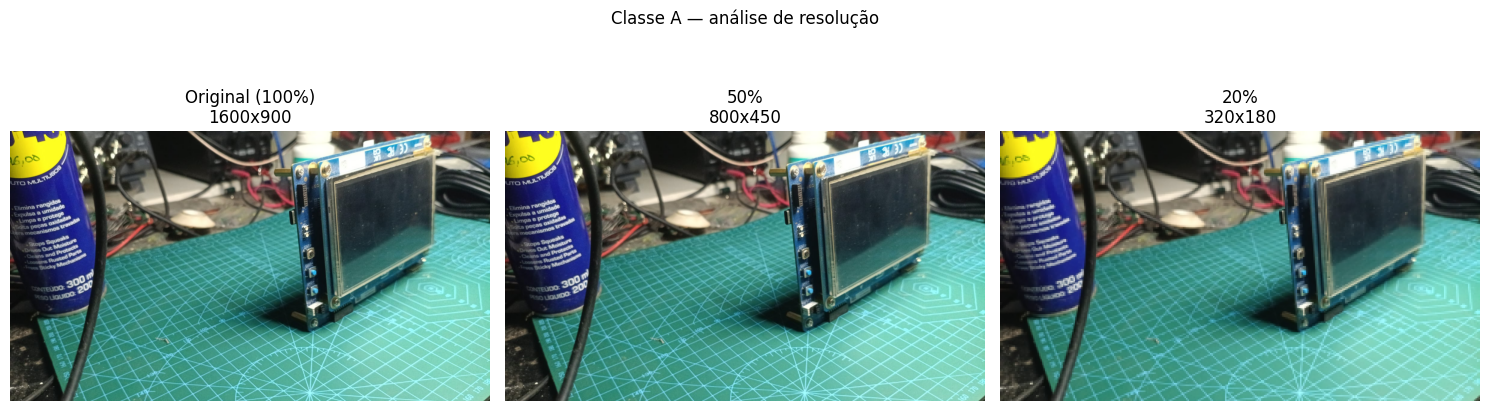

[2026-05-10 16:49:30] [994265017.py:mostrar_resolucoes:21] ✅ Resoluções exibidas para STM32N6-DK-frontal_esquerdo.jpeg


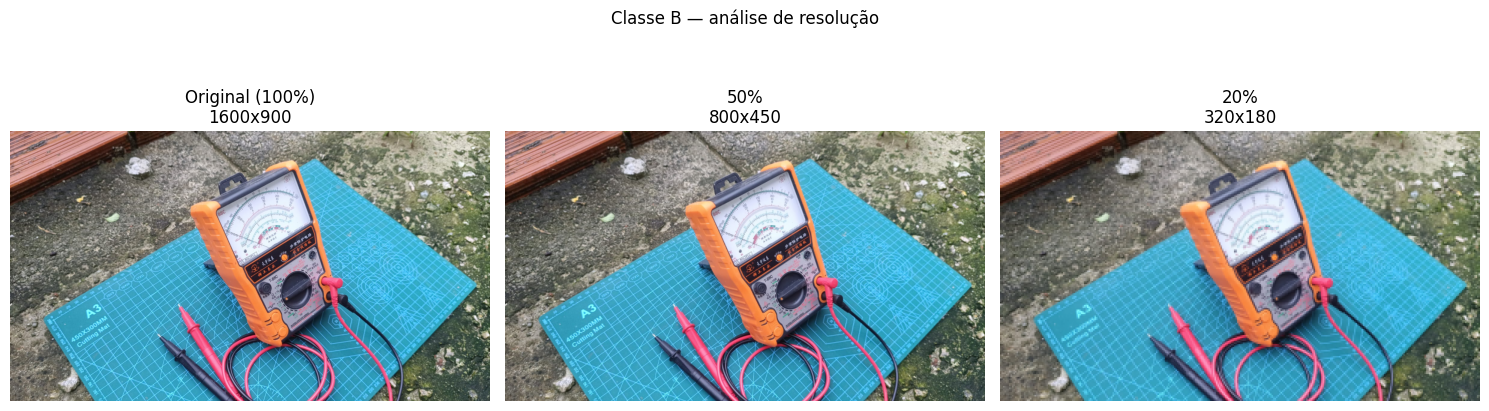

[2026-05-10 16:49:31] [994265017.py:mostrar_resolucoes:21] ✅ Resoluções exibidas para Multimetro-Analógico-Classico-frontal_esquerdo_luz_natural.jpeg.jpeg


In [26]:
def carregar_rgb(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def reduzir(img: np.ndarray, fator: float) -> np.ndarray:
    h, w = img.shape[:2]
    return cv2.resize(img, (max(1, int(w*fator)), max(1, int(h*fator))), interpolation=cv2.INTER_AREA)

def mostrar_resolucoes(path: Path, titulo: str):
    img = carregar_rgb(path)
    versoes = {'Original (100%)': img, '50%': reduzir(img, 0.5), '20%': reduzir(img, 0.2)}
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (nome, v) in zip(axes, versoes.items()):
        ax.imshow(v)
        ax.set_title(f'{nome}\n{v.shape[1]}x{v.shape[0]}')
        ax.axis('off')
    fig.suptitle(titulo)
    plt.tight_layout(); plt.show()
    log.info('✅ Resoluções exibidas para %s', path.name)

if imgs_A: mostrar_resolucoes(imgs_A[2], 'Classe A — análise de resolução')
if imgs_B: mostrar_resolucoes(imgs_B[4], 'Classe B — análise de resolução')

**Comentário (preencher):** perda de detalhe percebida e impacto em visão computacional (texturas finas, bordas, features SIFT/ORB, redes convolucionais).

### 7.B Espaço de cor — RGB, HSV, Escala de cinza

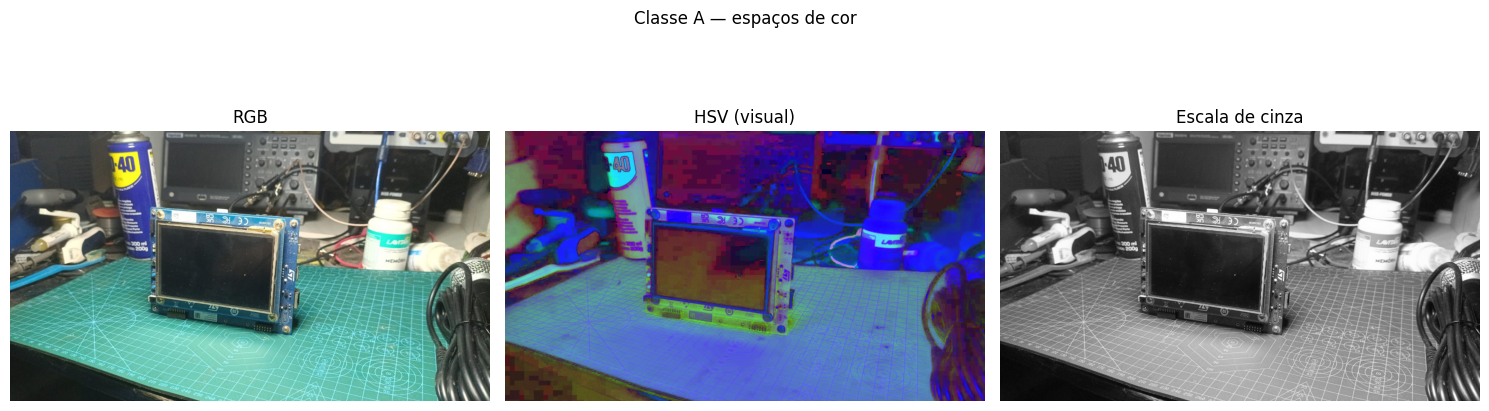

[2026-05-10 16:49:37] [713155040.py:mostrar_espacos_cor:11] ✅ Espaços de cor exibidos para STM32N6-DK-frontal_direito.jpeg


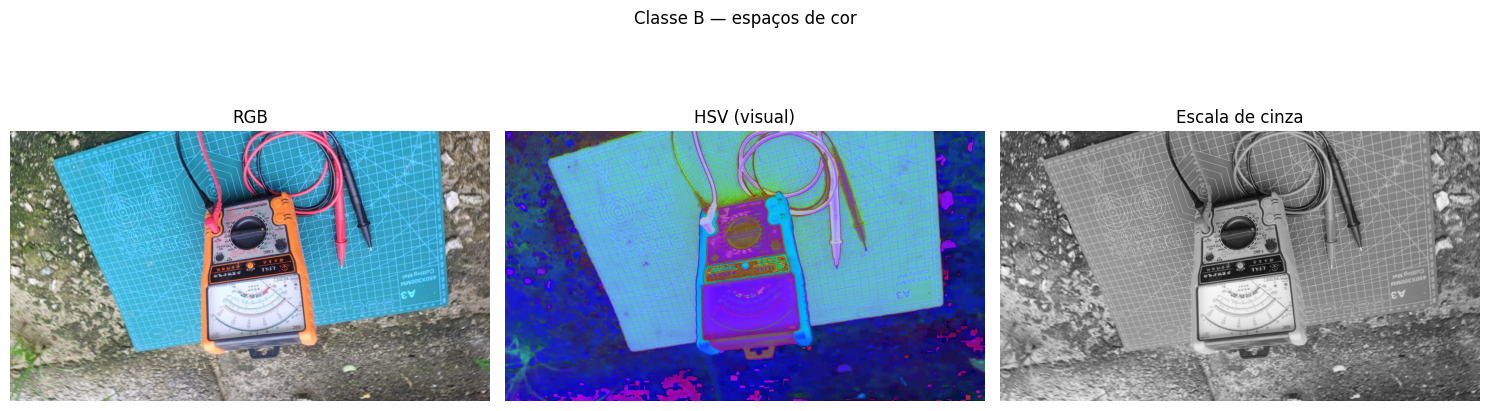

[2026-05-10 16:49:39] [713155040.py:mostrar_espacos_cor:11] ✅ Espaços de cor exibidos para Multimetro-Analógico-Classico-frontal_luz_natural.jpeg


In [27]:
def mostrar_espacos_cor(path: Path, titulo: str):
    rgb = carregar_rgb(path)
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(rgb);  axes[0].set_title('RGB');           axes[0].axis('off')
    axes[1].imshow(hsv);  axes[1].set_title('HSV (visual)');  axes[1].axis('off')
    axes[2].imshow(gray, cmap='gray'); axes[2].set_title('Escala de cinza'); axes[2].axis('off')
    fig.suptitle(titulo); plt.tight_layout(); plt.show()
    log.info('✅ Espaços de cor exibidos para %s', path.name)

if imgs_A: mostrar_espacos_cor(imgs_A[1], 'Classe A — espaços de cor')
if imgs_B: mostrar_espacos_cor(imgs_B[5], 'Classe B — espaços de cor')

**Registro textual (preencher):**
- Diferenças visuais ao converter RGB → HSV → cinza.
- Em qual tarefa cada espaço é mais útil (ex.: HSV para segmentação por cor, cinza para detecção de bordas/CNNs leves).

### 7.C Quantização — 256, 64, 32 e 2 níveis de cinza

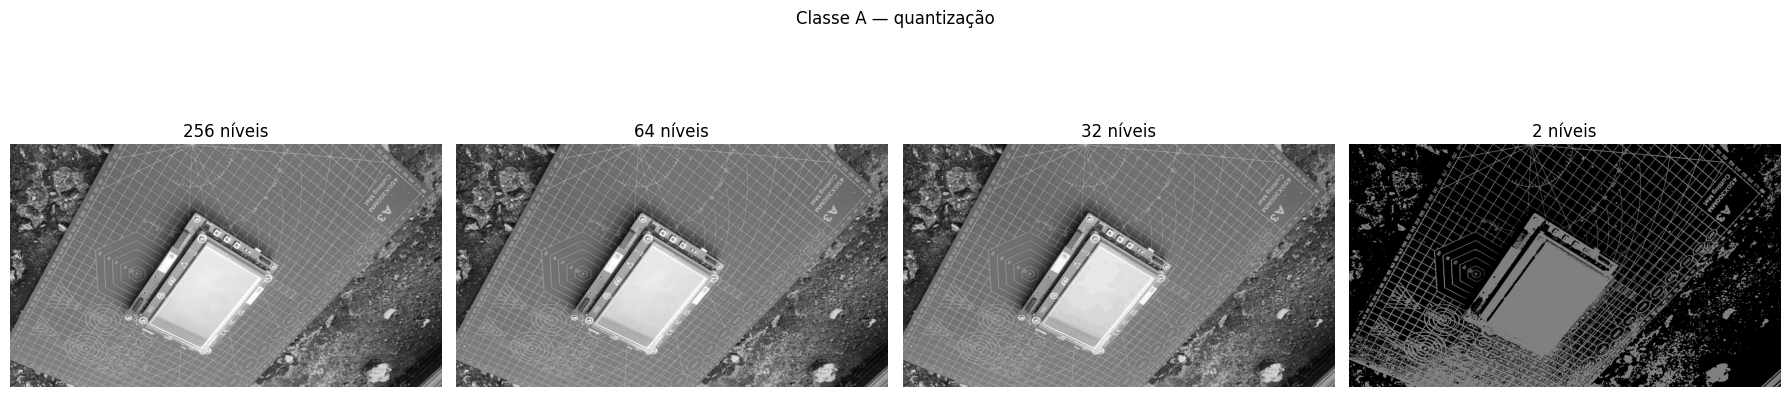

[2026-05-10 16:50:17] [554313160.py:mostrar_quantizacao:18] ✅ Quantizações exibidas para STM32N6-DK-frontal_esquerdo_luz_natural.jpeg


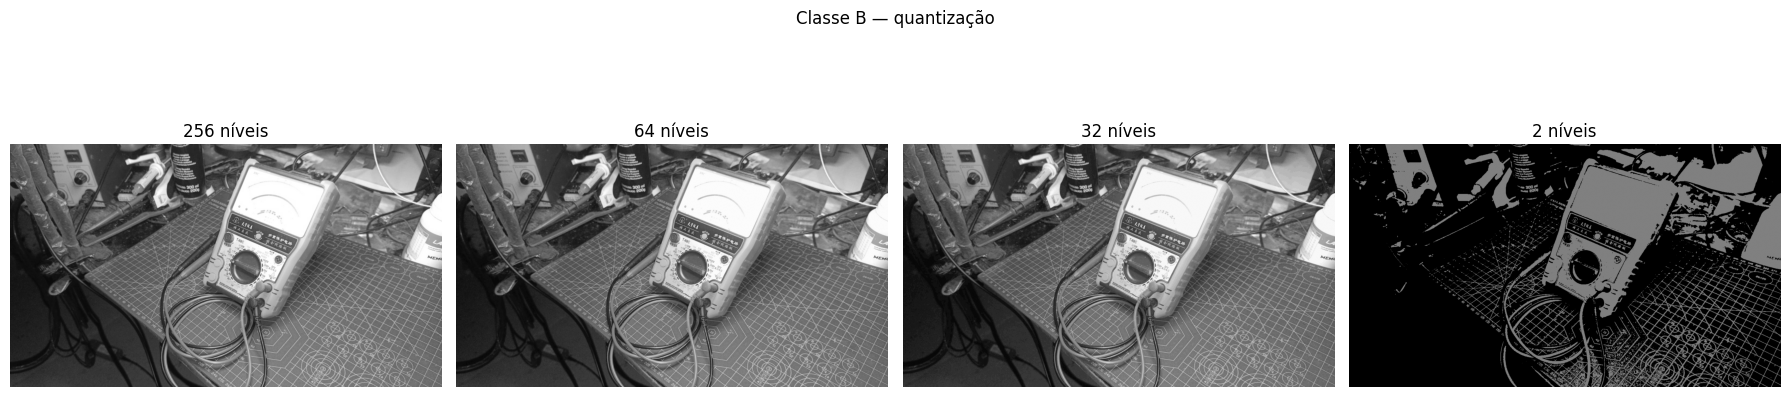

[2026-05-10 16:50:19] [554313160.py:mostrar_quantizacao:18] ✅ Quantizações exibidas para Multimetro-Analógico-Classico-frontal_direito.jpeg


In [30]:
def quantizar(gray: np.ndarray, niveis: int) -> np.ndarray:
    if niveis <= 1:
        return np.zeros_like(gray)
    passo = 256 // niveis
    q = (gray // passo) * passo
    return q.astype(np.uint8)

def mostrar_quantizacao(path: Path, titulo: str):
    rgb = carregar_rgb(path)
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    niveis = [256, 64, 32, 2]
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    for ax, n in zip(axes, niveis):
        q = quantizar(gray, n)
        ax.imshow(q, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{n} níveis'); ax.axis('off')
    fig.suptitle(titulo); plt.tight_layout(); plt.show()
    log.info('✅ Quantizações exibidas para %s', path.name)

if imgs_A: mostrar_quantizacao(imgs_A[3], 'Classe A — quantização')
if imgs_B: mostrar_quantizacao(imgs_B[2], 'Classe B — quantização')

**Registro (preencher):**
- O que muda visualmente ao reduzir os níveis (banding, perda de gradiente).
- Qual versão ainda é útil para o dataset e para qual aplicação (ex.: 2 níveis para OCR/binarização; 64 níveis para classificação leve).

### 7.D Formato de arquivo — JPEG vs PNG

[2026-05-10 16:50:29] [562697803.py:comparar_formatos:14] ✅ classe_A_exemplo | JPEG q=70 → 256.6 KB | PNG → 2258.5 KB


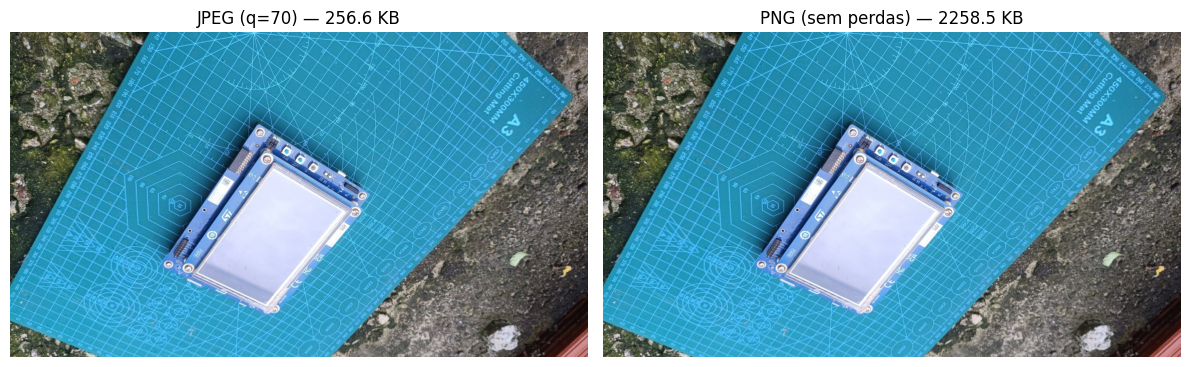

[2026-05-10 16:50:30] [562697803.py:comparar_formatos:14] ✅ classe_B_exemplo | JPEG q=70 → 216.7 KB | PNG → 2062.1 KB


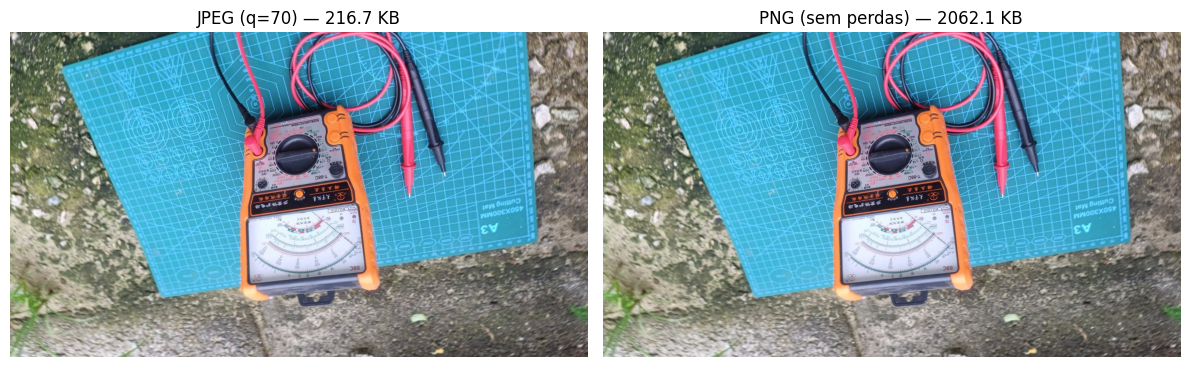

In [ ]:
OUT = Path('../dataset/_formatos'); OUT.mkdir(parents=True, exist_ok=True)

def comparar_formatos(path: Path, prefixo: str, jpeg_quality: int = 70):
    rgb = carregar_rgb(path)
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)

    jpg_path = OUT / f'{prefixo}.jpg'
    png_path = OUT / f'{prefixo}.png'
    cv2.imwrite(str(jpg_path), bgr, [cv2.IMWRITE_JPEG_QUALITY, jpeg_quality])
    cv2.imwrite(str(png_path), bgr, [cv2.IMWRITE_PNG_COMPRESSION, 3])

    jpg_kb = jpg_path.stat().st_size / 1024
    png_kb = png_path.stat().st_size / 1024
    log.info('✅ %s | JPEG q=%d → %.1f KB | PNG → %.1f KB', prefixo, jpeg_quality, jpg_kb, png_kb)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(carregar_rgb(jpg_path)); axes[0].set_title(f'JPEG (q={jpeg_quality}) — {jpg_kb:.1f} KB'); axes[0].axis('off')
    axes[1].imshow(carregar_rgb(png_path)); axes[1].set_title(f'PNG (sem perdas) — {png_kb:.1f} KB'); axes[1].axis('off')
    plt.tight_layout(); plt.show()
    return {'jpeg_kb': jpg_kb, 'png_kb': png_kb}

if imgs_A: comparar_formatos(imgs_A[3], 'classe_A_exemplo')
if imgs_B: comparar_formatos(imgs_B[5], 'classe_B_exemplo')

## 8 Reflexão crítica final

Os arquivos apresentam tamanhos variados conforme detalhes das fotos.

Humanamente falando o VSH demonstrou uma melhor distinção das bordas me deixando em dúvida sobre seu uso em relação aos de tom de cinza.

Ainda não estou muito afinado para fazer uma critica sobre o processo de tratamento de imagens, más fiquei intrigado com o formato HSV. Também não percebi distinção de qualidade entre o formato JPG e PNG, não sei se por deficiência visual ou porque na prática realmente não se destaca tal diferença. No projeto profissional com CV pretendo trabalhar com câmeras IR, e poderia dizer que inicialmente trabalhar com escalas de Cinza seria um bom ínicio de trabalho até ter as câmeras, acredito que os dados em formato RAW das câmeras IR são de fato escalas de cinza.

<p align="center">
  <img src="https://capsule-render.vercel.app/api?type=waving&color=0:10b981,50:1a56db,100:0f172a&height=120&section=footer" width="100%" alt="Footer"/>
</p>
